In [ ]:
import tensorflow as tf
print("TF Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF Version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import files
files.upload()

import os
os.makedirs("/root/.kaggle", exist_ok=True)
os.system("mv kaggle.json /root/.kaggle/kaggle.json")
os.system("chmod 600 /root/.kaggle/kaggle.json")


!pip install -q kaggle scikit-learn seaborn matplotlib
print("✅ All dependencies ready!")

Saving kaggle.json to kaggle.json
✅ All dependencies ready!


In [ ]:
from google.colab import files
import os, shutil

shutil.rmtree("/root/.kaggle", ignore_errors=True)
uploaded = files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "wb") as f:
    f.write(uploaded["kaggle.json"])
os.chmod("/root/.kaggle/kaggle.json", 0o600)

import json
with open("/root/.kaggle/kaggle.json") as f:
    creds = json.load(f)
print("✅ Kaggle authenticated as:", creds["username"])

Saving kaggle.json to kaggle.json
✅ Kaggle authenticated as: reemyousri


In [ ]:
!kaggle datasets download -d grassknoted/asl-alphabet --force

import zipfile
print("📦 Unzipping... (this may take ~1 min)")
with zipfile.ZipFile("asl-alphabet.zip", "r") as z:
    z.extractall("./data_raw")

import os
train_path = "./data_raw/asl_alphabet_train/asl_alphabet_train"
classes = sorted(os.listdir(train_path))
print(f"✅ Done! Found {len(classes)} classes:")
print(classes)

Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
License(s): GPL-2.0
 99% 1.02G/1.03G [00:15<00:00, 94.5MB/s]
100% 1.03G/1.03G [00:15<00:00, 72.7MB/s]
📦 Unzipping... (this may take ~1 min)
✅ Done! Found 29 classes:
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [ ]:
import os, shutil, random
from pathlib import Path

SRC = "./data_raw/asl_alphabet_train/asl_alphabet_train"
TRAIN_DIR = "./data/train"
VAL_DIR   = "./data/val"
TEST_DIR  = "./data/test"

TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
TEST_RATIO  = 0.10

random.seed(42)

print("📂 Organizing dataset into train/val/test...")

for class_name in sorted(os.listdir(SRC)):
    class_path = os.path.join(SRC, class_name)
    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)
    random.shuffle(images)

    n = len(images)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)

    splits = {
        TRAIN_DIR: images[:n_train],
        VAL_DIR:   images[n_train:n_train + n_val],
        TEST_DIR:  images[n_train + n_val:],
    }

    for split_dir, split_images in splits.items():
        dest = os.path.join(split_dir, class_name)
        os.makedirs(dest, exist_ok=True)
        for img in split_images:
            shutil.copy(os.path.join(class_path, img), os.path.join(dest, img))

print("✅ Done! Dataset split summary:")
for split, path in [("Train", TRAIN_DIR), ("Val", VAL_DIR), ("Test", TEST_DIR)]:
    total = sum(len(os.listdir(os.path.join(path, c)))
                for c in os.listdir(path))
    print(f"  {split}: {total} images across {len(os.listdir(path))} classes")

📂 Organizing dataset into train/val/test...
✅ Done! Dataset split summary:
  Train: 69600 images across 29 classes
  Val: 8700 images across 29 classes
  Test: 8700 images across 29 classes


Found 69600 images belonging to 29 classes.
Found 8700 images belonging to 29 classes.
Found 8700 images belonging to 29 classes.
✅ Generators ready!
   Classes : 29
   Train   : 69600 images
   Val     : 8700 images
   Test    : 8700 images


/tmp/ipython-input-4074874811.py:65: UserWarning: Glyph 129306 (\N{RAISED BACK OF HAND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129306 (\N{RAISED BACK OF HAND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


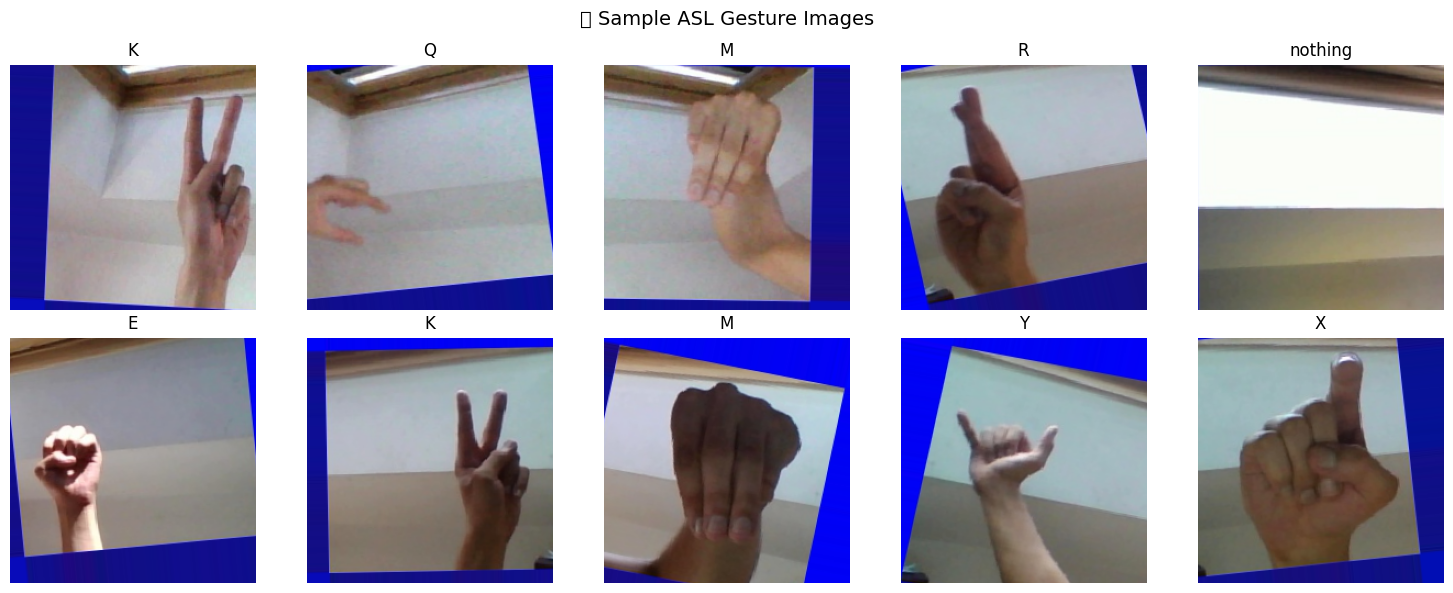

✅ Sample images displayed!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest",
)

val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_directory(
    "./data/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
)

val_gen = val_test_datagen.flow_from_directory(
    "./data/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
)

test_gen = val_test_datagen.flow_from_directory(
    "./data/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
)

NUM_CLASSES = len(train_gen.class_indices)
CLASS_NAMES = list(train_gen.class_indices.keys())
print(f"✅ Generators ready!")
print(f"   Classes : {NUM_CLASSES}")
print(f"   Train   : {train_gen.samples} images")
print(f"   Val     : {val_gen.samples} images")
print(f"   Test    : {test_gen.samples} images")


fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("🤚 Sample ASL Gesture Images", fontsize=14)
sample_batch, sample_labels = next(train_gen)
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_batch[i])
    ax.set_title(CLASS_NAMES[np.argmax(sample_labels[i])])
    ax.axis("off")
plt.tight_layout()
plt.show()
print("✅ Sample images displayed!")

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)

base_model.trainable = False

print(f"Base model layers     : {len(base_model.layers)}")
print(f"Trainable layers now  : {sum(1 for l in base_model.layers if l.trainable)}")

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))

x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs, name="ASL_GestureDetector")

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()
print("\n✅ Model built successfully!")
print(f"   Total params     : {model.count_params():,}")
print(f"   Output classes   : {NUM_CLASSES} gestures")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Base model layers     : 154
Trainable layers now  : 0


Model: "ASL_GestureDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,057,757 (11.66 MB)

 Trainable params: 797,213 (3.04 MB)

 Non-trainable params: 2,260,544 (8.62 MB)


✅ Model built successfully!
   Total params     : 3,057,757
   Output classes   : 29 gestures


In [ ]:
from tensorflow.keras import callbacks

print("="*50)
print("🚀 PHASE 1: Training custom head only")
print("="*50)

cb_early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=4,
    restore_best_weights=True, verbose=1
)
cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5,
    patience=2, verbose=1
)
cb_checkpoint = callbacks.ModelCheckpoint(
    "best_phase1.keras", monitor="val_accuracy",
    save_best_only=True, verbose=1
)


history1 = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=[cb_early_stop, cb_reduce_lr, cb_checkpoint],
)

final_acc = history1.history["val_accuracy"][-1] * 100
print(f"\n✅ Phase 1 Done!")
print(f"   Best Val Accuracy: {final_acc:.2f}%")

🚀 PHASE 1: Training custom head only


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.7190 - loss: 0.9587
Epoch 1: val_accuracy improved from -inf to 0.95966, saving model to best_phase1.keras
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 820s 368ms/step - accuracy: 0.7191 - loss: 0.9585 - val_accuracy: 0.9597 - val_loss: 0.1211 - learning_rate: 0.0010
Epoch 2/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.8877 - loss: 0.3590
Epoch 2: val_accuracy improved from 0.95966 to 0.97264, saving model to best_phase1.keras
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 771s 354ms/step - accuracy: 0.8877 - loss: 0.3590 - val_accuracy: 0.9726 - val_loss: 0.0871 - learning_rate: 0.0010
Epoch 3/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.9043 - loss: 0.3086
Epoch 3: val_accuracy improved from 0.97264 to 0.98011, saving model to best_phase1.keras
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 778s 358ms/step - accuracy: 0.9043 - loss: 0.3086 - val_accuracy: 0.9801 - val_loss: 0.0585 - learning_rate: 0.0010
Epoch 4/10
2175/2175 ━

In [ ]:
print("="*50)
print("🔥 PHASE 2: Fine-tuning MobileNetV2 top layers")
print("="*50)

base_model.trainable = True

FINE_TUNE_AT = 100
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

trainable_count = sum(1 for l in model.layers if l.trainable)
print(f"🔓 Unfrozen layers : {trainable_count}")
print(f"🔒 Frozen layers   : {len(model.layers) - trainable_count}")

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

cb_checkpoint2 = callbacks.ModelCheckpoint(
    "best_phase2.keras", monitor="val_accuracy",
    save_best_only=True, verbose=1
)

history2 = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=[cb_early_stop, cb_reduce_lr, cb_checkpoint2],
)

final_acc2 = max(history2.history["val_accuracy"]) * 100
print(f"\n✅ Phase 2 Done!")
print(f"   Phase 1 Best Accuracy : 98.36%")
print(f"   Phase 2 Best Accuracy : {final_acc2:.2f}%")
print(f"   Improvement           : +{final_acc2 - 98.36:.2f}%")

🔥 PHASE 2: Fine-tuning MobileNetV2 top layers
🔓 Unfrozen layers : 9
🔒 Frozen layers   : 0
Epoch 1/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.7140 - loss: 1.2262
Epoch 1: val_accuracy improved from -inf to 0.97609, saving model to best_phase2.keras
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 831s 371ms/step - accuracy: 0.7141 - loss: 1.2260 - val_accuracy: 0.9761 - val_loss: 0.0835 - learning_rate: 1.0000e-05
Epoch 2/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.9255 - loss: 0.2661
Epoch 2: val_accuracy improved from 0.97609 to 0.98333, saving model to best_phase2.keras
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 866s 398ms/step - accuracy: 0.9255 - loss: 0.2661 - val_accuracy: 0.9833 - val_loss: 0.0497 - learning_rate: 1.0000e-05
Epoch 3/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.9571 - loss: 0.1494
Epoch 3: val_accuracy improved from 0.98333 to 0.99138, saving model to best_phase2.keras
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 797s 366ms/step - accuracy: 0.9571 - los

/tmp/ipython-input-436591878.py:38: UserWarning: Glyph 129306 (\N{RAISED BACK OF HAND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-436591878.py:39: UserWarning: Glyph 129306 (\N{RAISED BACK OF HAND}) missing from font(s) DejaVu Sans.
  plt.savefig("training_curves.png", dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129306 (\N{RAISED BACK OF HAND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


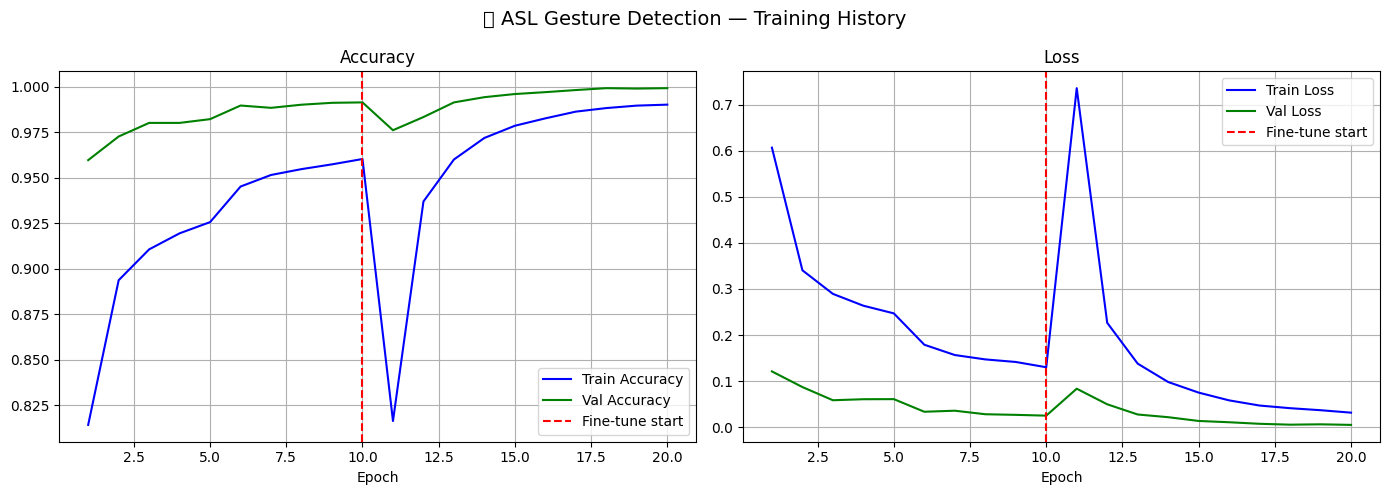

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



📊 Evaluating on Test Set...
272/272 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.9977 - loss: 0.0060

🎯 Test Accuracy : 99.77%
   Test Loss     : 0.0059

📊 Generating Confusion Matrix...
272/272 ━━━━━━━━━━━━━━━━━━━━ 19s 56ms/step


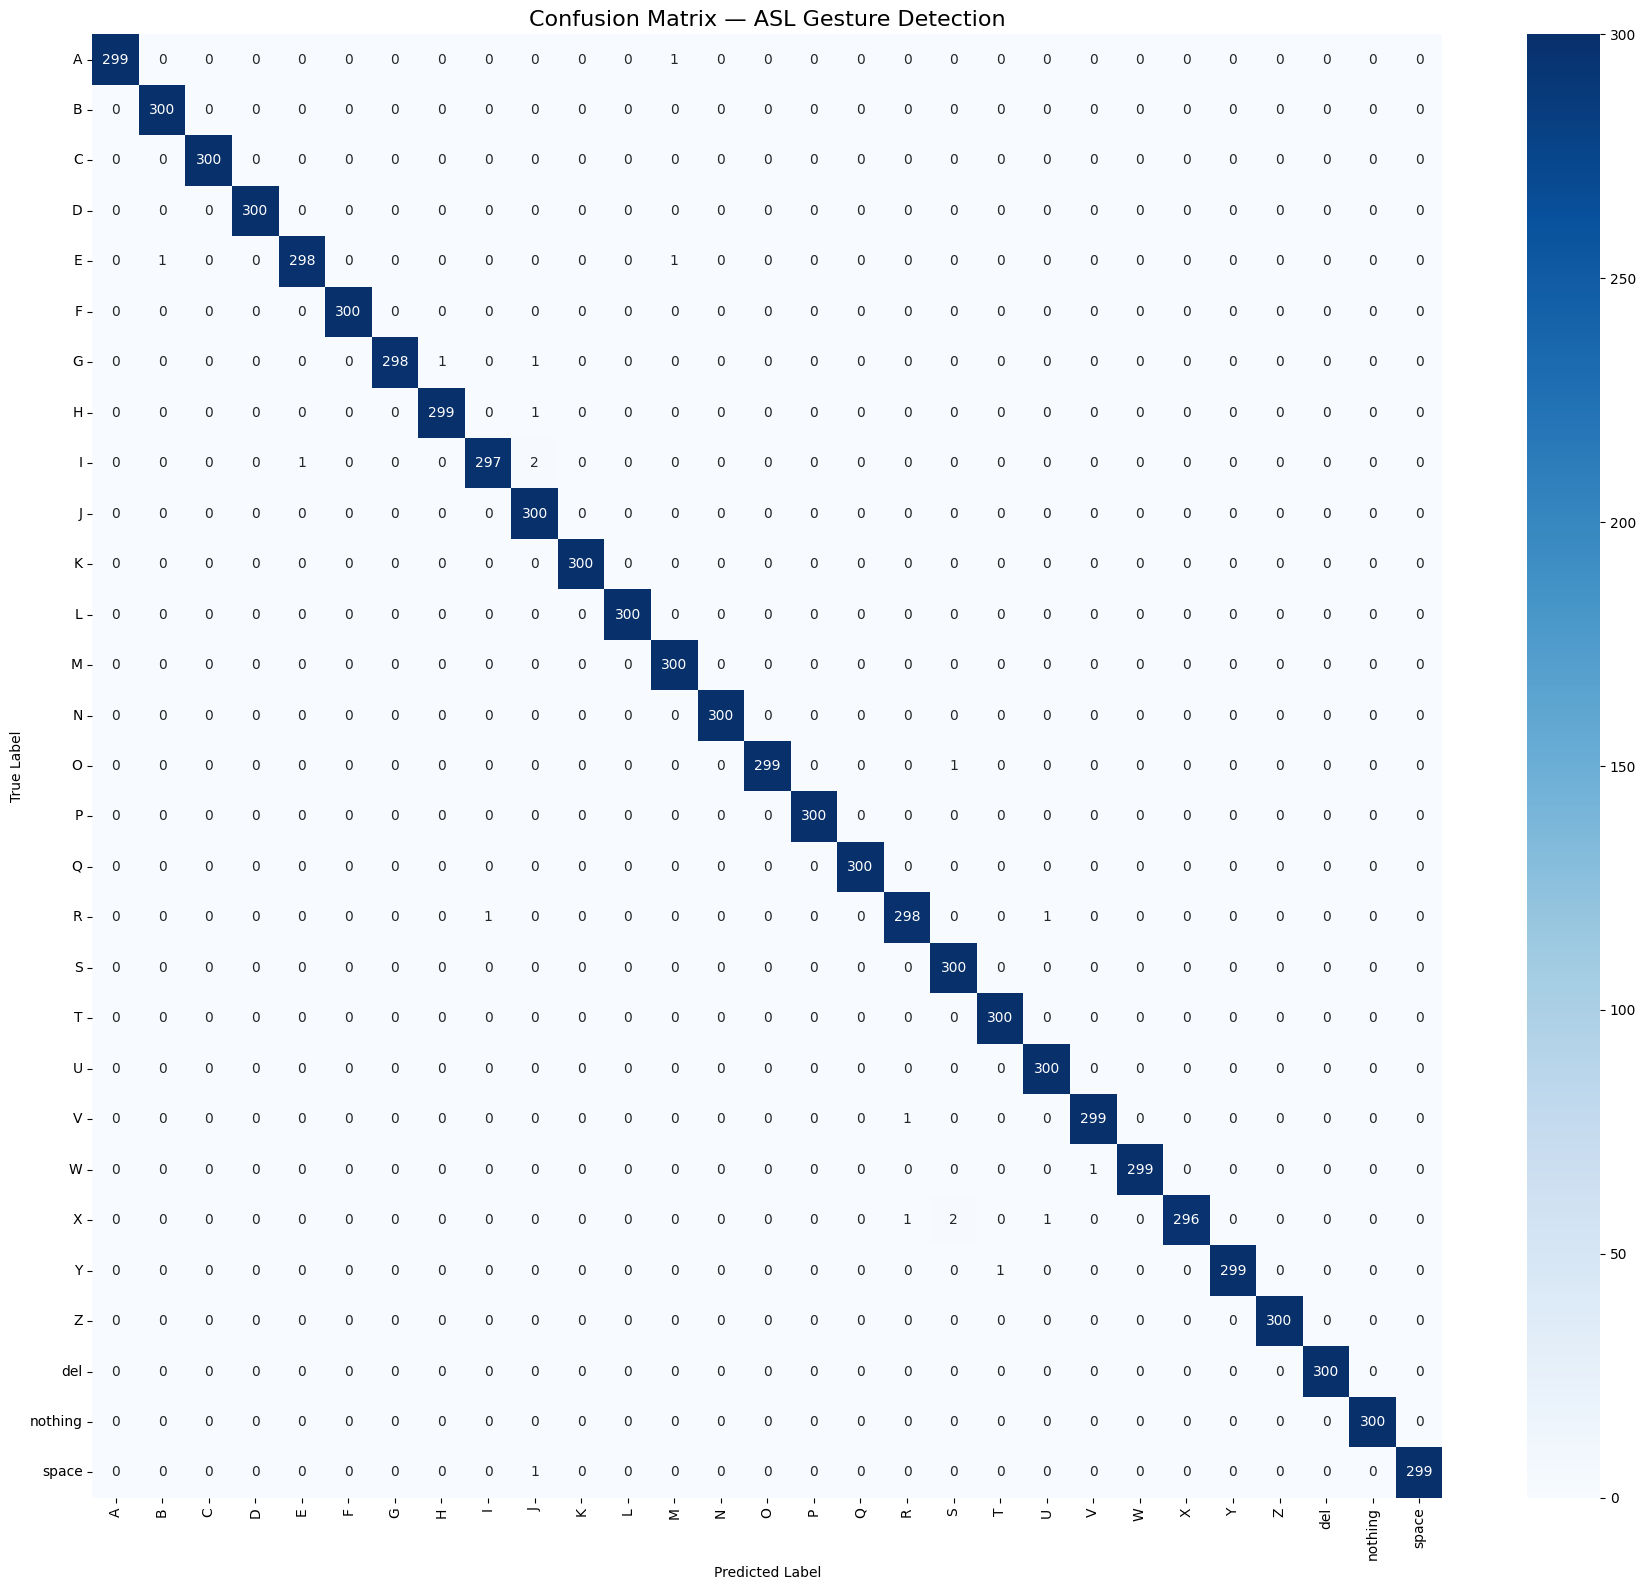


📋 Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       300
           B       1.00      1.00      1.00       300
           C       1.00      1.00      1.00       300
           D       1.00      1.00      1.00       300
           E       1.00      0.99      0.99       300
           F       1.00      1.00      1.00       300
           G       1.00      0.99      1.00       300
           H       1.00      1.00      1.00       300
           I       1.00      0.99      0.99       300
           J       0.98      1.00      0.99       300
           K       1.00      1.00      1.00       300
           L       1.00      1.00      1.00       300
           M       0.99      1.00      1.00       300
           N       1.00      1.00      1.00       300
           O       1.00      1.00      1.00       300
           P       1.00      1.00      1.00       300
           Q       1.00      1.00      1.00       300
 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

best_model = tf.keras.models.load_model("best_phase2.keras")

acc   = history1.history["val_accuracy"] + history2.history["val_accuracy"]
loss  = history1.history["val_loss"]     + history2.history["val_loss"]
tacc  = history1.history["accuracy"]     + history2.history["accuracy"]
tloss = history1.history["loss"]         + history2.history["loss"]
ep    = range(1, len(acc) + 1)
split = len(history1.history["accuracy"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("🤚 ASL Gesture Detection — Training History", fontsize=14)

axes[0].plot(ep, tacc, label="Train Accuracy", color="blue")
axes[0].plot(ep, acc,  label="Val Accuracy",   color="green")
axes[0].axvline(split, color="red", linestyle="--", label="Fine-tune start")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(ep, tloss, label="Train Loss", color="blue")
axes[1].plot(ep, loss,  label="Val Loss",   color="green")
axes[1].axvline(split, color="red", linestyle="--", label="Fine-tune start")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

print("\n📊 Evaluating on Test Set...")
test_loss, test_acc = best_model.evaluate(test_gen, verbose=1)
print(f"\n🎯 Test Accuracy : {test_acc * 100:.2f}%")
print(f"   Test Loss     : {test_loss:.4f}")

print("\n📊 Generating Confusion Matrix...")
y_pred = np.argmax(best_model.predict(test_gen), axis=1)
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(18, 16))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix — ASL Gesture Detection", fontsize=16)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))